## Neural-State Similarity Across Sampling Thresholds

This section compares the most frequently visited neural states generated at different minimum-visit thresholds.

Similarity is evaluated using correlation-based heatmaps across the sweep and Euclidean-distance matrices for selected threshold pairs.

In [5]:
import os
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()

if (current_dir / "pearson_correlation_confusion_matrix.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "pearson_correlation_confusion_matrix.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise RuntimeError(f"Could not locate project root from {current_dir}")

PROJECT_ROOT = str(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Working directory:", os.getcwd())

Project root: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model
Working directory: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model


In [6]:
%load_ext autoreload
%autoreload 2

import os
import torch

import figure2_generation as f2g
import small_model
import pearson_correlation_confusion_matrix as pr

In [7]:
SEED = 42

checkpoint_path = os.path.join(PROJECT_ROOT, "post_stage1_model_sd42.pt")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Post-stage-1 model not found: {checkpoint_path}")

model = small_model.RNN().to(f2g.device)
model.load_state_dict(torch.load(checkpoint_path, map_location=f2g.device, weights_only=True))
model.eval()

print("Loaded model:", checkpoint_path)
print("Device:", f2g.device)

Loaded model: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model/post_stage1_model_sd42.pt
Device: mps


In [8]:
sweep_results = f2g.sweep_data_gen(model, step_size=5, min_attempts=50, max_attempts=101, sd=SEED)
print("Sweep thresholds:", sorted(sweep_results.keys()))


[Log] Generating data for min_attempts = 50...
[Log] cache already exists for min_visits=50
[Log] Completed data generation for min_attempts = 50.

[Log] Generating data for min_attempts = 55...
[Log] cache already exists for min_visits=55
[Log] Completed data generation for min_attempts = 55.

[Log] Generating data for min_attempts = 60...
[Log] cache already exists for min_visits=60
[Log] Completed data generation for min_attempts = 60.

[Log] Generating data for min_attempts = 65...
[Log] cache already exists for min_visits=65
[Log] Completed data generation for min_attempts = 65.

[Log] Generating data for min_attempts = 70...
[Log] cache already exists for min_visits=70
[Log] Completed data generation for min_attempts = 70.

[Log] Generating data for min_attempts = 75...
[Log] cache already exists for min_visits=75
[Log] Completed data generation for min_attempts = 75.

[Log] Generating data for min_attempts = 80...
[Log] cache already exists for min_visits=80
[Log] Completed dat

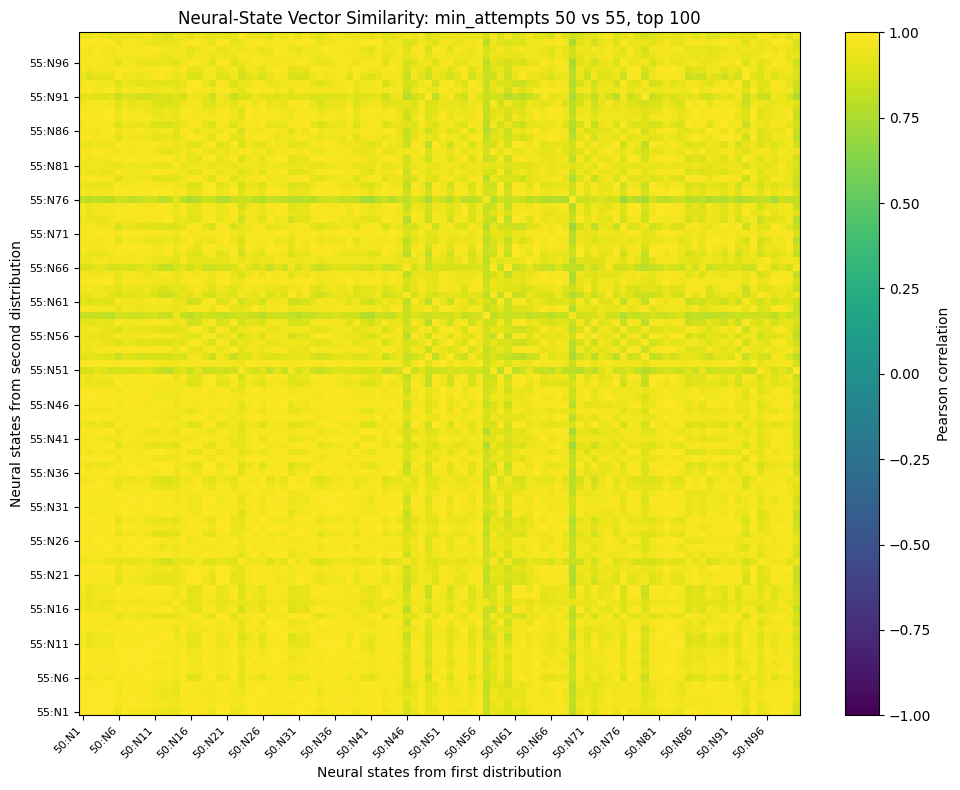

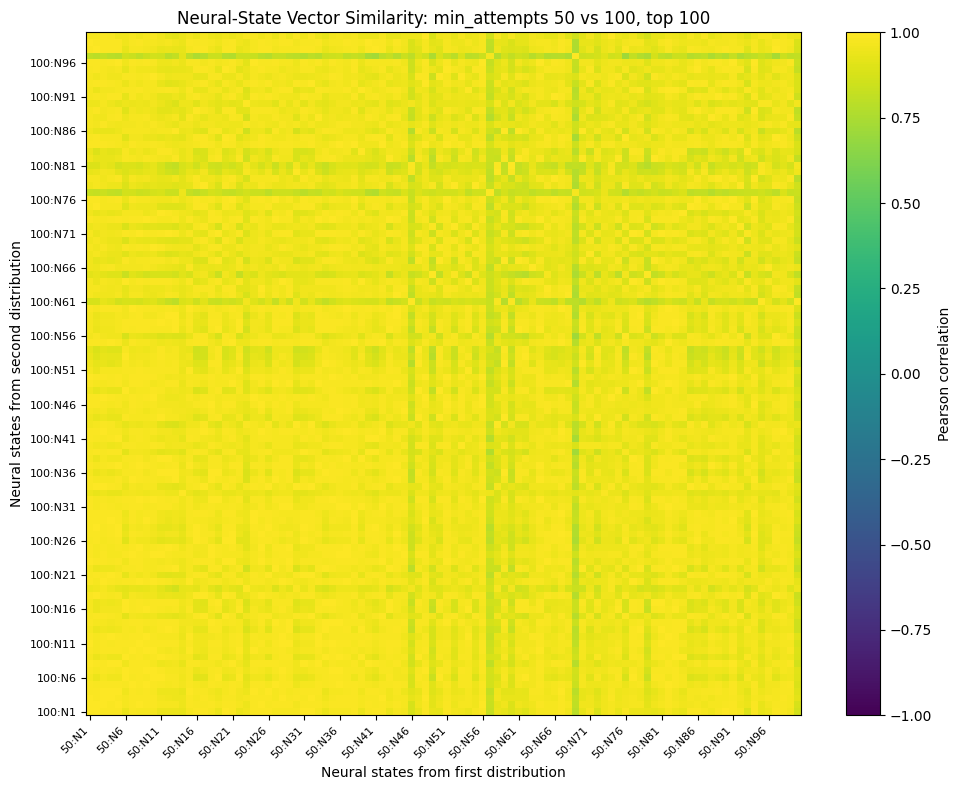

In [9]:
pr.neural_state_vector_similarity_heatmaps(sweep_results=sweep_results, top_k=100)

### Euclidean Neural-State Distance: Min 50 vs Min 55

Compare the top 100 neural states from the min-visits=50 and min-visits=55 transition dictionaries using pairwise Euclidean distance.

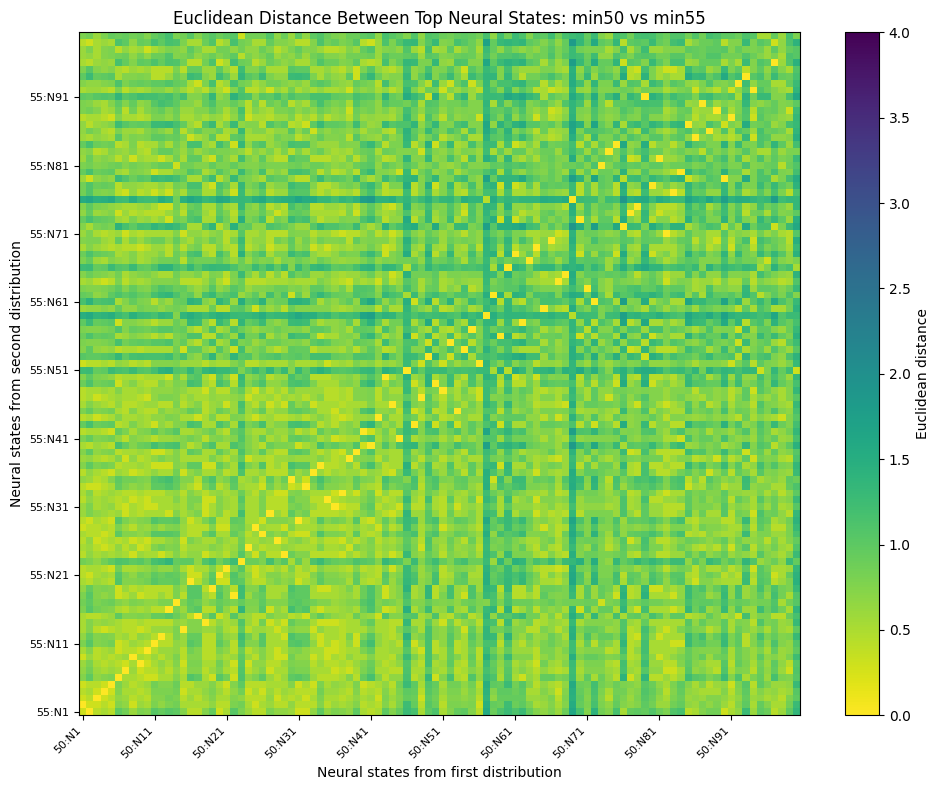

In [10]:
matrix_50_55_euc, x_labels_50, y_labels_55, counts_50, counts_55 = pr.neural_state_euclidean_confusion_matrix(sweep_results, min_attempts_a=50, min_attempts_b=55, top_k=100)
pr.plot_neural_state_euclidean_confusion_matrix(matrix_50_55_euc, x_labels_50, y_labels_55, title="Euclidean Distance Between Top Neural States: min50 vs min55", tick_step=10)

### Euclidean Neural-State Distance: Min 50 vs Min 100

Compare the top 100 neural states from the min-visits=50 and min-visits=100 transition dictionaries.

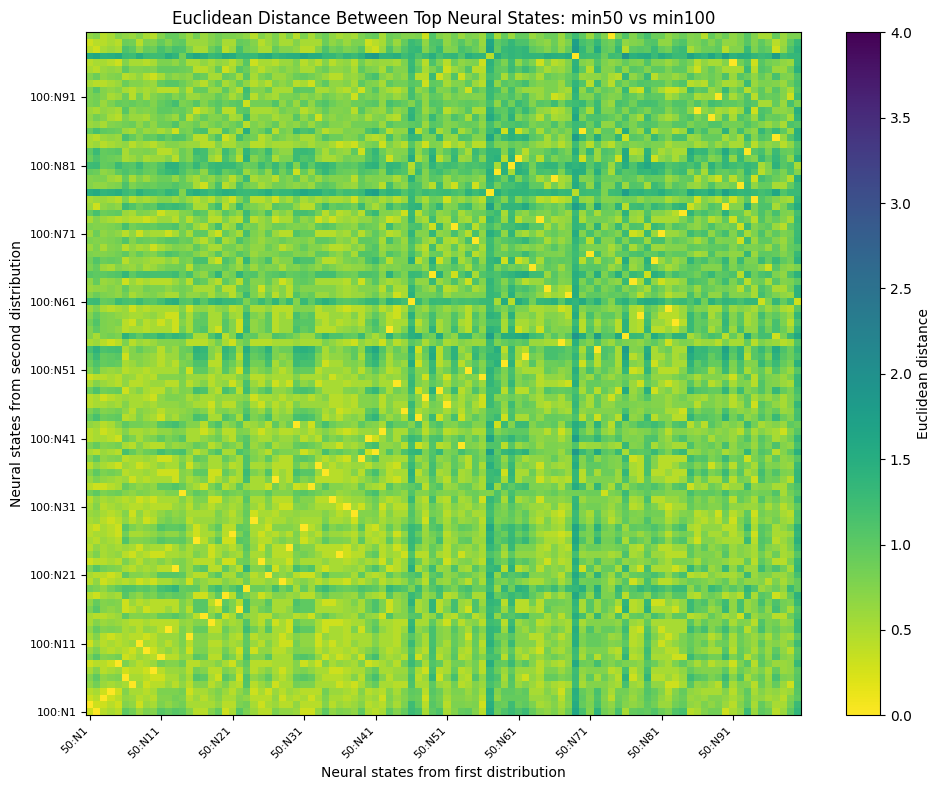

In [11]:
matrix_50_100_euc, x_labels_50, y_labels_100, counts_50, counts_100 = pr.neural_state_euclidean_confusion_matrix(sweep_results, min_attempts_a=50, min_attempts_b=100, top_k=100)
pr.plot_neural_state_euclidean_confusion_matrix(matrix_50_100_euc, x_labels_50, y_labels_100, title="Euclidean Distance Between Top Neural States: min50 vs min100", tick_step=10)